# 01 — Exploración de Datos

Este notebook permite explorar los datasets descargados:
- Cargar el dataset y revisar estructura
- Ver distribución de clases
- Visualizar imágenes de ejemplo con sus anotaciones
- Verificar integridad de los datos

In [1]:
# === Setup para Google Colab ===
import os

if os.getenv('COLAB_RELEASE_TAG'):
    from google.colab import drive
    drive.mount('/content/drive')
    %cd /content/drive/MyDrive/neurodrive
    !pip install -q ultralytics albumentations
    print('✅ Entorno Colab configurado')
else:
    # En local, asegurar que estamos en el directorio del proyecto
    os.chdir(os.path.join(os.path.dirname(os.path.abspath('.')), ''))
    print('✅ Entorno local detectado')

✅ Entorno local detectado


In [2]:
# === Configuración ===
# Cambiar estos valores según el dataset a explorar

DATASET_NAME = 'tier1_road_vehicles'  # nombre del dataset
DATASET_CONFIG = f'configs/datasets/{DATASET_NAME}.yaml'  # config YAML
DATA_DIR = 'data/raw'  # directorio de datos crudos

In [ ]:
import sys
sys.path.insert(0, '.')

from pathlib import Path
import yaml
import cv2
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Cargar configuración del dataset
with open(DATASET_CONFIG, 'r', encoding='utf-8') as f:
    dataset_config = yaml.safe_load(f)

print(f"Dataset: {dataset_config['dataset']['name']}")
print(f"Formato: {dataset_config['dataset']['format']}")
print(f"Clases: {dataset_config['dataset']['classes']}")
print(f"Notas: {dataset_config['dataset']['notes']}")

Dataset: Road Vehicle Images
Formato: yolo
Clases: ['vehicle']
Notas: Carreteras de Bangladesh. Formato YOLO nativo.


## Estructura del Dataset

Revisamos la estructura de archivos del dataset descargado.

In [5]:
dataset_path = Path(DATA_DIR) / DATASET_NAME

if not dataset_path.exists():
    print(f'⚠️ Dataset no encontrado en: {dataset_path}')
    print('Ejecuta primero: python scripts/download_datasets.py --dataset', DATASET_NAME)
else:
    # Listar archivos y directorios
    for item in sorted(dataset_path.rglob('*'))[:30]:
        relative = item.relative_to(dataset_path)
        prefix = '📁' if item.is_dir() else '📄'
        print(f'{prefix} {relative}')
    
    # Contar archivos por tipo
    extensions = Counter(f.suffix.lower() for f in dataset_path.rglob('*') if f.is_file())
    print(f'\nArchivos por tipo: {dict(extensions)}')

📁 trafic_data
📄 trafic_data\data_1.yaml
📁 trafic_data\train
📁 trafic_data\train\images
📄 trafic_data\train\images\01_jpg.rf.8d8a2f0f90d5b83893cd252acd832c93.jpg
📄 trafic_data\train\images\02_jpg.rf.65a084066fc353cd023eb5c953f40efe.jpg
📄 trafic_data\train\images\03_jpg.rf.4532f2db68433995da09f54e215160f3.jpg
📄 trafic_data\train\images\04_jpg.rf.c0b83432c4d09c7cbeaac18e14c4a54a.jpg
📄 trafic_data\train\images\05_jpg.rf.11a2e7ce391a1e74960099f7923f27f5.jpg
📄 trafic_data\train\images\06_jpeg.rf.14bdc2005d8029bbe9f24fad4b6af7ea.jpg
📄 trafic_data\train\images\07_jpg.rf.8447b11632c1b63ab0e127f16625e0d2.jpg
📄 trafic_data\train\images\08_jpg.rf.837e69c4e93e62472911c1d18be143a4.jpg
📄 trafic_data\train\images\09_jpg.rf.42406b1c067f04bf73349bd75b2e3fa8.jpg
📄 trafic_data\train\images\100_jpg.rf.971dbb99e07828d1655d69bbfb7136be.jpg
📄 trafic_data\train\images\101_jpg.rf.2737e79396d350c7eeb5bf867c346077.jpg
📄 trafic_data\train\images\102_jpg.rf.2d884248dcc60b7d6b93f61df77921df.jpg
📄 trafic_data\train\i

## Distribución de Clases

Analizamos cuántas instancias hay de cada clase en el dataset.

In [7]:
# Buscar archivos de labels
labels_dir = None
for candidate in ['trafic_data/train/labels', 'trafic_data/valid/labels', 'labels', 'train/labels']:
    p = dataset_path / candidate
    if p.exists():
        labels_dir = p
        break

if labels_dir is None:
    print('⚠️ No se encontró directorio de labels')
else:
    # Contar clases
    class_counts = Counter()
    total_boxes = 0
    
    for label_file in labels_dir.glob('*.txt'):
        with open(label_file) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    class_counts[int(parts[0])] += 1
                    total_boxes += 1
    
    print(f'Total de labels: {len(list(labels_dir.glob("*.txt")))}')
    print(f'Total de bounding boxes: {total_boxes}')
    print(f'\nDistribución de clases:')
    for cls_id, count in sorted(class_counts.items()):
        print(f'  Clase {cls_id}: {count} ({count/total_boxes*100:.1f}%)')

Total de labels: 2704
Total de bounding boxes: 21764

Distribución de clases:
  Clase 0: 70 (0.3%)
  Clase 1: 43 (0.2%)
  Clase 2: 372 (1.7%)
  Clase 3: 427 (2.0%)
  Clase 4: 2909 (13.4%)
  Clase 5: 4632 (21.3%)
  Clase 6: 3 (0.0%)
  Clase 7: 169 (0.8%)
  Clase 8: 93 (0.4%)
  Clase 9: 822 (3.8%)
  Clase 10: 1949 (9.0%)
  Clase 11: 1083 (5.0%)
  Clase 12: 31 (0.1%)
  Clase 13: 3336 (15.3%)
  Clase 14: 37 (0.2%)
  Clase 15: 798 (3.7%)
  Clase 16: 41 (0.2%)
  Clase 17: 2734 (12.6%)
  Clase 18: 1411 (6.5%)
  Clase 19: 693 (3.2%)
  Clase 20: 111 (0.5%)


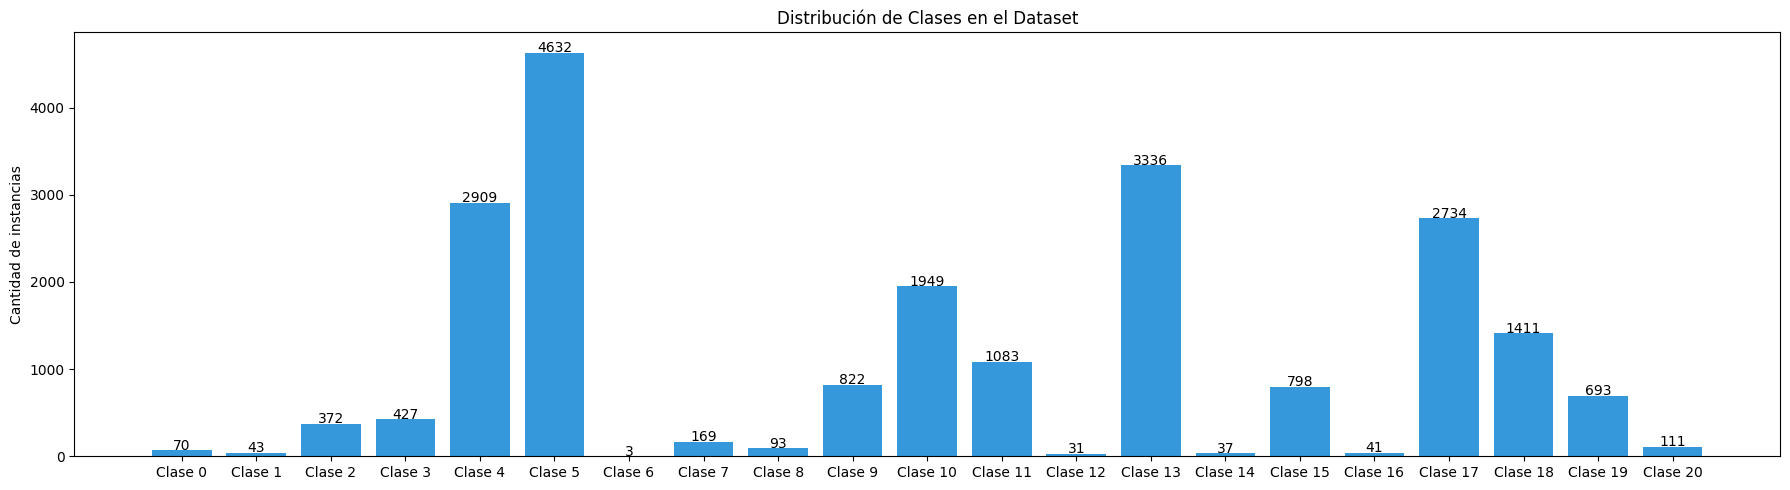

In [9]:
# Gráfica de distribución
if labels_dir and class_counts:
    fig, ax = plt.subplots(figsize=(18, 5))
    clases = [f'Clase {c}' for c in sorted(class_counts.keys())]
    conteos = [class_counts[c] for c in sorted(class_counts.keys())]
    
    bars = ax.bar(clases, conteos, color='#3498db')
    ax.set_title('Distribución de Clases en el Dataset')
    ax.set_ylabel('Cantidad de instancias')
    
    for bar, count in zip(bars, conteos):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(count), ha='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()

## Visualización de Muestras

Visualizamos algunas imágenes con sus bounding boxes para verificar la calidad de las anotaciones.

In [ ]:
# Buscar directorio de imágenes
images_dir = None
for candidate in ['images', 'train/images', 'images/train']:
    p = dataset_path / candidate
    if p.exists():
        images_dir = p
        break

if images_dir and labels_dir:
    # Tomar 6 imágenes de ejemplo
    sample_images = list(images_dir.glob('*.jpg'))[:6]
    if not sample_images:
        sample_images = list(images_dir.glob('*.png'))[:6]
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, img_path in enumerate(sample_images):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        
        # Leer labels
        label_file = labels_dir / f'{img_path.stem}.txt'
        if label_file.exists():
            with open(label_file) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        cls_id = int(parts[0])
                        xc, yc, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                        x1 = int((xc - bw/2) * w)
                        y1 = int((yc - bh/2) * h)
                        x2 = int((xc + bw/2) * w)
                        y2 = int((yc + bh/2) * h)
                        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                        cv2.putText(img, f'Clase {cls_id}', (x1, y1-5),
                                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
        
        axes[idx].imshow(img)
        axes[idx].set_title(img_path.name, fontsize=9)
        axes[idx].axis('off')
    
    # Ocultar ejes sobrantes
    for idx in range(len(sample_images), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Muestras del Dataset con Anotaciones', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print('⚠️ No se encontraron directorios de imágenes o labels')

## Validación de Integridad

Verificamos que el dataset sea consistente: que cada imagen tenga su label y viceversa.

In [ ]:
from src.data.validate import validate_dataset

if images_dir and labels_dir:
    stats = validate_dataset(
        images_dir=str(images_dir),
        labels_dir=str(labels_dir),
        verbose=True,
    )
else:
    print('⚠️ Configura images_dir y labels_dir manualmente para validar')

## Siguiente Paso

Una vez explorado el dataset, continúa con:
- **02_entrenamiento_baseline.ipynb**: Entrenar el primer modelo YOLO